# DB_MALARIA ablation: metric vs deltaprop hard-negative fraction

Pulls the single run from the `ablation_db_malaria_frac_hard` wandb project, recovers the per-(frac_hard, model) rows from its history, and plots deltaprop across hard-negative fractions with the chemprop baseline as a horizontal reference line.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()` and split on the `model` column ourselves. chemprop is invariant to `frac_hard`, so it appears once with `frac_hard = NaN`.

In [48]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation"
RUN_PREFIX = "db_malaria_frac_hard"
RUN_NAME = None  # set to an exact run name to pin a specific run; otherwise use the latest
METRIC = "test_average_precision"  # swap for test_mcc, test_f1, test_roc_auc, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
if RUN_NAME is not None:
    run = next(r for r in runs if r.name == RUN_NAME)
else:
    # Runs are named '<prefix>_<timestamp>'; pick the most recent matching run.
    matches = [r for r in runs if r.name.startswith(RUN_PREFIX)]
    run = max(matches, key=lambda r: r.created_at)
run.name, run.id

('db_malaria_frac_hard_20260620_183712', 'c5alwn1w')

In [49]:
# Full, unsampled history -> one row per (frac_hard, model, seed).
df = pd.DataFrame(run.scan_history())
df = df[["frac_hard", "seed", "model", "n_train", METRIC]].sort_values(
    ["model", "frac_hard", "seed"]
)
df

,frac_hard,seed,model,n_train,test_average_precision
0,NaN,42,chemprop,1518,0.047498
12,NaN,123,chemprop,1513,0.073603
24,NaN,456,chemprop,1520,0.137986
36,NaN,789,chemprop,1518,0.125095
48,NaN,1011,chemprop,1514,0.136001
...,...,...,...,...,...
71,1.0,1213,deltaprop,1514,0.086779
83,1.0,1415,deltaprop,1518,0.086317
95,1.0,1617,deltaprop,1520,0.087329
107,1.0,1819,deltaprop,1520,0.127868


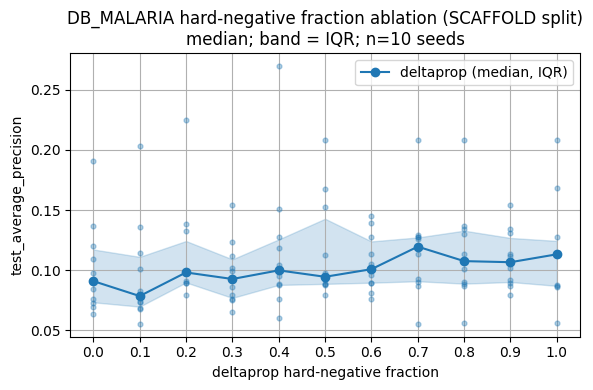

In [52]:
# Aggregate across seeds: median + IQR (Q1-Q3) per hard-negative fraction.
# Average precision is mildly right-skewed across seeds, so the median is a more honest
# summary of typical performance than the mean; raw seed points are overlaid for transparency.
delta_rows = df[df["model"] == "deltaprop"]
delta = (
    delta_rows
    .groupby("frac_hard")[METRIC]
    .agg(
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        count="count"
    )
    .reset_index()
    .sort_values("frac_hard")
)
chemprop = df[df["model"] == "chemprop"][METRIC]
n_seeds = delta_rows["seed"].nunique()

fig, ax = plt.subplots(figsize=(6, 4))

# Median as a line, IQR (Q1-Q3) as a shaded band, raw seed points overlaid.
(line,) = ax.plot(
    delta["frac_hard"],
    delta["median"],
    marker="o",
    label="deltaprop (median, IQR)",
)
color = line.get_color()
ax.fill_between(
    delta["frac_hard"],
    delta["q1"],
    delta["q3"],
    color=color,
    alpha=0.2,
)
ax.scatter(
    delta_rows["frac_hard"],
    delta_rows[METRIC],
    color=color,
    s=12,
    alpha=0.35,
    zorder=3,
)

# if len(chemprop):
#     ax.axhline(
#         chemprop.median(),
#         color="gray",
#         linestyle="--",
#         label="chemprop (baseline)",
#     )
#     ax.fill_between(
#         delta["frac_hard"],
#         chemprop.quantile(0.25),
#         chemprop.quantile(0.75),
#         color="gray",
#         alpha=0.15,
#     )

ax.set_xticks(delta["frac_hard"])
ax.set_xlabel("deltaprop hard-negative fraction")
ax.set_ylabel(METRIC)
ax.set_title(
    f"DB_MALARIA hard-negative fraction ablation (SCAFFOLD split)\nmedian; band = IQR; n={n_seeds} seeds"
)
ax.grid(True)
ax.legend()
fig.tight_layout()
# fig.savefig("db_malaria_hard_negatives_ablation.png", dpi=150)
plt.show()

In [53]:
delta

,frac_hard,median,q1,q3,count
0,0.0,0.090860,0.073225,0.117158,10
1,0.1,0.078422,0.069640,0.111030,10
2,0.2,0.098051,0.089719,0.124197,10
3,0.3,0.092603,0.076871,0.108957,10
4,0.4,0.099798,0.087670,0.125558,10
5,0.5,0.094445,0.088551,0.142739,10
6,0.6,0.100773,0.089540,0.123885,10
7,0.7,0.119528,0.090751,0.127181,10
8,0.8,0.107489,0.088754,0.132817,10
9,0.9,0.106578,0.090116,0.126761,10
